In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from scipy.stats import kendalltau, pearsonr

In [ ]:
data_folder = 'path/to/data/folder/'
filename = data_folder + 'spring24_solvtemp_jpm.csv'
df = pd.read_csv(filename)


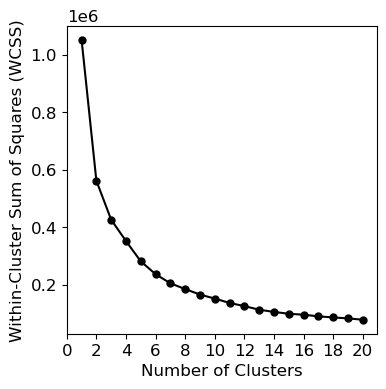

In [14]:
# Generate train and test data
input_df = df[['CB', 'DCB', 'TOL', 'annealing_temperature']].values
inertia = []
range_clusters = range(1, 21)  # Trying 1 to 20 clusters
for k in range_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(input_df)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(4, 4))
plt.plot(range_clusters, inertia, marker='o', markersize=5, color='black')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(np.arange(0, 21, 2))
plt.show()


In [15]:
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(input_df)
test_indices = []
# For each cluster, choose 5 points
for cluster in np.unique(cluster_labels):
    cluster_points = np.where(cluster_labels == cluster)[0]
    rng = np.random.RandomState(42)  # Set the random seed
    representative_indices = rng.choice(cluster_points, size=5, replace=False)
    test_indices.extend(representative_indices)
test_indices = np.array(test_indices)
train_indices = np.setdiff1d(np.arange(len(df)), test_indices)
print("Train indices:", train_indices)
print("Test indices:", test_indices)

Train indices: [  2   3   4   5   6   7   8   9  11  12  14  15  16  17  18  19  20  21
  22  23  24  25  26  27  28  29  31  32  33  34  35  36  37  39  40  41
  42  44  46  48  49  50  51  53  55  56  58  59  60  61  63  64  65  66
  67  68  70  71  72  73  74  76  77  78  79  80  81  83  84  85  87  88
  89  90  91  92  93  94  95  97  98 101 102 103 105 107 108 109 110 112
 113 114 115 116 119 120 121 122 123 124 125 126 127]
Test indices: [ 96  54  10  52  99 118  82 104  86  30 106  47   0  45 111  62  75   1
 100  69  38  57  13 117  43]


model 0

input - processing conditions

output - Sheet resistance

In [16]:
input_data = df[['CB', 'DCB', 'TOL', 'annealing_temperature']].values
output_data = df[['Sheet Resistance']].values
lower_limit = np.array([0, 0, 0, 30])
upper_limit = np.array([100, 100, 100, 270])
X_train = input_data[train_indices]
y_train = output_data[train_indices]
X_test = input_data[test_indices]
y_test = output_data[test_indices]
mask_train = y_train <= 100000  
mask_test = y_test <= 100000    
y_train = y_train[mask_train.flatten()]
X_train = X_train[mask_train.flatten()]
y_test = y_test[mask_test.flatten()]
X_test = X_test[mask_test.flatten()]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
model_0 = RandomForestRegressor(n_estimators=50, criterion = "absolute_error",  min_samples_split=10, random_state=42)
model_0.fit(X_train, y_train)
y_pred_train = model_0.predict(X_train)
y_pred_test = model_0.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f'R²_train: {r2_train}')
print(f'R²_test: {r2_test}')

print(f'RMSE_train: {rmse_train}')
print(f'RMSE_test: {rmse_test}')

print(f'MAE_train: {mae_train}')
print(f'MAE_test: {mae_test}')


kendall_tau_train = kendalltau(y_train.flatten(), y_pred_train.flatten()).correlation
kendall_tau_test = kendalltau(y_test.flatten(), y_pred_test.flatten()).correlation

print(f'Kendall Tau (Train): {kendall_tau_train}')
print(f'Kendall Tau (Test): {kendall_tau_test}')

pearson_corr_train, _ = pearsonr(y_train.flatten(), y_pred_train.flatten())
pearson_corr_test, _ = pearsonr(y_test.flatten(), y_pred_test.flatten())

print(f'Pearson Correlation (Train): {pearson_corr_train}')
print(f'Pearson Correlation (Test): {pearson_corr_test}')




(96, 4) (96, 1) (25, 4) (25, 1)
R²_train: 0.6461065087043498
R²_test: 0.41492184959942724
RMSE_train: 7459.7244962628765
RMSE_test: 11355.096788171624
MAE_train: 4945.308611134271
MAE_test: 8475.185866415599
Kendall Tau (Train): 0.7003072196768493
Kendall Tau (Test): 0.48414090838827883
Pearson Correlation (Train): 0.8161029035253874
Pearson Correlation (Test): 0.6443055871377131


/Users/ankushmishra/miniconda3/envs/hamiltonian/lib/python3.8/site-packages/sklearn/base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


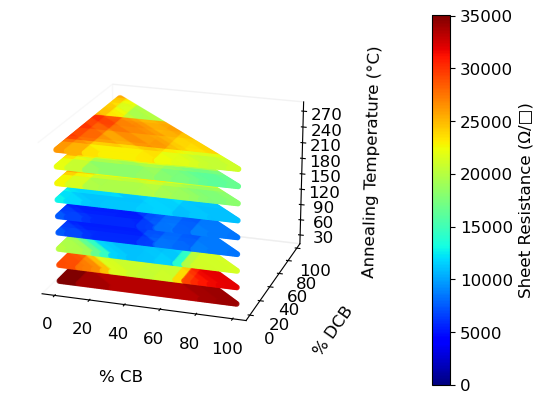

In [17]:
x1_s = np.linspace(start=lower_limit[0], stop=upper_limit[0], num=101, retstep=False)
x2_s = np.linspace(start=lower_limit[1], stop=upper_limit[1], num=101, retstep=False)
x3_s = np.linspace(start=lower_limit[2], stop=upper_limit[2], num=101, retstep=False)
x4_s = np.linspace(start=lower_limit[3], stop=upper_limit[3], num=9, retstep=False)
x1 = []
x2 = []
x3 = []
x4 = []
x1_min, x1_max = x1_s[0], x1_s[-1]
x2_min, x2_max = x2_s[0], x2_s[-1]
x3_min, x3_max = x3_s[0], x3_s[-1]
x4_min, x4_max = x4_s[0], x4_s[-1]
x1_grid, x2_grid, x3_grid, x4_grid = np.meshgrid(x1_s, x2_s, x3_s, x4_s, indexing='ij')
sum_locations = x1_grid + x2_grid + x3_grid 
mask = (sum_locations == 100)
filtered_x1 = x1_grid[mask]
filtered_x2 = x2_grid[mask]
filtered_x3 = x3_grid[mask]
filtered_x4 = x4_grid[mask]
x1 = filtered_x1.ravel().tolist()
x2 = filtered_x2.ravel().tolist()
x3 = filtered_x3.ravel().tolist()
x4 = filtered_x4.ravel().tolist()
x_plot= np.column_stack((x1, x2, x3, x4))
x_plot_normalized = x_plot 
y_pred_plot = model_0.predict(x_plot_normalized)


#Plottin it
size = 12
matplotlib.rcParams.update({'font.size': size})
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
scatter_y_pred_plot = ax.scatter(
    x_plot[:, 0], x_plot[:, 1], x_plot[:, 3],
    c=y_pred_plot, cmap='jet', s=10, vmin = 0
)


cbar_y_pred = plt.colorbar(scatter_y_pred_plot, ax=ax, pad=0.2)
cbar_y_pred.set_label('Sheet Resistance (Ω/□)', fontsize=size)

ax.set_xlabel(f'% CB',fontsize=size, labelpad=15)
ax.set_ylabel(f'% DCB',fontsize=size,labelpad=15)
ax.set_zlabel(f'Annealing Temperature (°C)',fontsize=size,labelpad=15)

ax.set_zticks([30, 60, 90, 120, 150, 180, 210, 240, 270])
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.set_facecolor('w')
fig.set_facecolor('w')
ax.view_init(elev=20, azim=-72)
plt.show()
